<a href="https://colab.research.google.com/github/parika8ec-hub/AI_Project_Deploy_Model/blob/main/AI_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task-1 Problem Definition and Dataset Selection:

**Problem Definition:**

Employee attrition refers to employees leaving an organization either voluntarily or involuntarily. High attrition can negatively impact organizations by increasing recruitment and training costs, reducing productivity, and causing the loss of experienced employees.

The objective of this project is to build a machine learning classification model that predicts whether an employee is likely to leave the company (Attrition: Yes/No) based on personal, job-related, and workplace factors such as monthly income, overtime, job satisfaction, work-life balance, and years at the company.

This is a binary classification problem, where the model learns patterns from historical employee data to predict future attrition risk.

This problem is important because accurate attrition prediction can help organizations:

- Identify employees at high risk of leaving
- Improve retention strategies
- Reduce hiring and training costs
- Maintain workforce stability
- Improve employee satisfaction and productivity

**Dataset Selection:**

The dataset used for this project is the IBM HR Analytics Employee Attrition & Performance Dataset from Kaggle. This dataset contains employee-related information such as demographics, salary details, job roles, performance indicators and workplace satisfaction metrics.The dataset includes 1,470 employee records and multiple features related to employee behavior and organizational factors.

**Dataset Source:**

Kaggle: IBM HR Analytics Employee Attrition & Performance Dataset

https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset

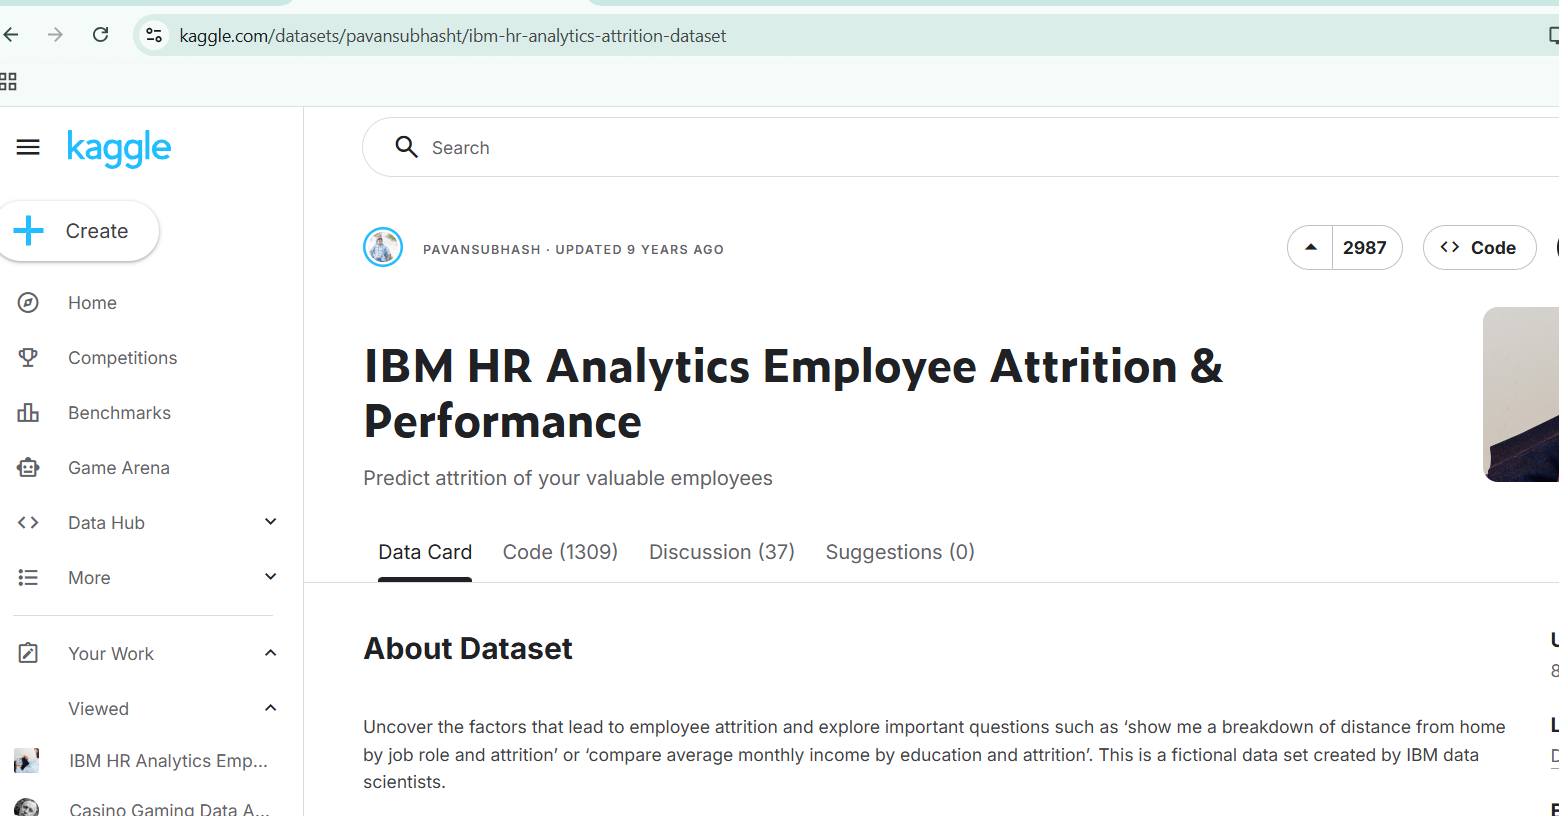

**Dataset Description:**

The dataset contains employee records with features such as:

- Age
- Department
- Job Role
- Monthly Income
- Job Satisfaction
- Work-Life Balance
- Overtime
- Years at Company
- Education Level
- Distance from Home
- Attrition (Target Variable: Yes/No)

**Why this dataset is suitable and selected?**

- It represents a real-world HR analytics problem.
- It contains both numerical and categorical features.
- It includes a clearly defined target variable (Attrition).
- It is clean and well-structured for machine learning analysis.
- It enables exploration of employee behavior patterns.

**Challenge in the Dataset:**

One significant challenge in this dataset is class imbalance, where significantly more employees stay in the company compared to those who leave. This makes predicting attrition more difficult and affects metrics such as recall and F1-score.

The dataset also contains multiple features, requiring preprocessing techniques such as encoding, scaling, feature selection and hyperparameter tuning.

**Justification:**

This dataset is ideal for developing a predictive model because employee retention is a major concern for many organizations. By identifying employees who may leave in advance, companies can take proactive actions to improve retention and reduce operational costs.

# Task-2 Data Preprocessing and Exploration:

In [30]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report,auc,roc_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV
import joblib

**Load Dataset:**

In [31]:
# Load dataset
IBM_HR_data = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

# Display first few rows
print('Display few rows of dataset:')
print(IBM_HR_data.head().to_string())

Display few rows of dataset:
   Age Attrition     BusinessTravel  DailyRate              Department  DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  EnvironmentSatisfaction  Gender  HourlyRate  JobInvolvement  JobLevel                JobRole  JobSatisfaction MaritalStatus  MonthlyIncome  MonthlyRate  NumCompaniesWorked Over18 OverTime  PercentSalaryHike  PerformanceRating  RelationshipSatisfaction  StandardHours  StockOptionLevel  TotalWorkingYears  TrainingTimesLastYear  WorkLifeBalance  YearsAtCompany  YearsInCurrentRole  YearsSinceLastPromotion  YearsWithCurrManager
0   41       Yes      Travel_Rarely       1102                   Sales                 1          2  Life Sciences              1               1                        2  Female          94               3         2        Sales Executive                4        Single           5993        19479                   8      Y      Yes                 11                  3                         

**Understanding the dataset:**

In [32]:
# Dataset info
print('Dataset Information:')
print(IBM_HR_data.info())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  Job

In [33]:
# Summary statistics
print('Summary Statistics:')
print(IBM_HR_data.describe())

Summary Statistics:
               Age    DailyRate  ...  YearsSinceLastPromotion  YearsWithCurrManager
count  1470.000000  1470.000000  ...              1470.000000           1470.000000
mean     36.923810   802.485714  ...                 2.187755              4.123129
std       9.135373   403.509100  ...                 3.222430              3.568136
min      18.000000   102.000000  ...                 0.000000              0.000000
25%      30.000000   465.000000  ...                 0.000000              2.000000
50%      36.000000   802.000000  ...                 1.000000              3.000000
75%      43.000000  1157.000000  ...                 3.000000              7.000000
max      60.000000  1499.000000  ...                15.000000             17.000000

[8 rows x 26 columns]


In [34]:
# Check missing values
print('Is any Missing Values? ',IBM_HR_data.isnull().sum().any())

Is any Missing Values?  False


**Missing Value Handling:**

After examining the IBM HR Analytics Employee Attrition dataset, no missing values were found in any of the features. Therefore, missing data handling techniques such as imputation or removal were not required for this dataset.

**Preprocess the data and Outlier detection:**

In [35]:
#Encoding categorical variables

# Initialize LabelEncoder to convert categorical variables into numerical format
le = LabelEncoder()

# Loop through all columns in the dataset that have object (categorical) data type
# and apply Label Encoding to convert each category into numeric values
for column in IBM_HR_data.select_dtypes(include=['object']).columns:
    IBM_HR_data[column] = le.fit_transform(IBM_HR_data[column])

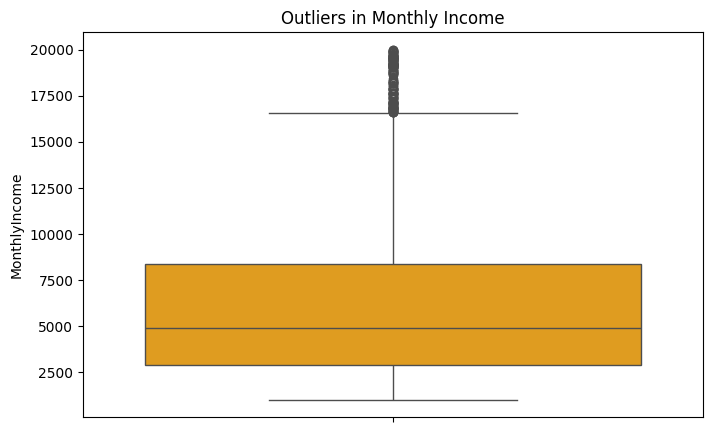

In [36]:
#Create outlier detection Plot
plt.figure(figsize=(8,5))#set plot size
sns.boxplot(data=IBM_HR_data['MonthlyIncome'],color='orange')#create boxplot
plt.title("Outliers in Monthly Income")#add title
plt.show()#display plot

**Outlier Boxplot Insights:**

- High-income outliers exist (~17,000 range)
- Most employees fall in lower-mid salary range

**Data Visualization:**

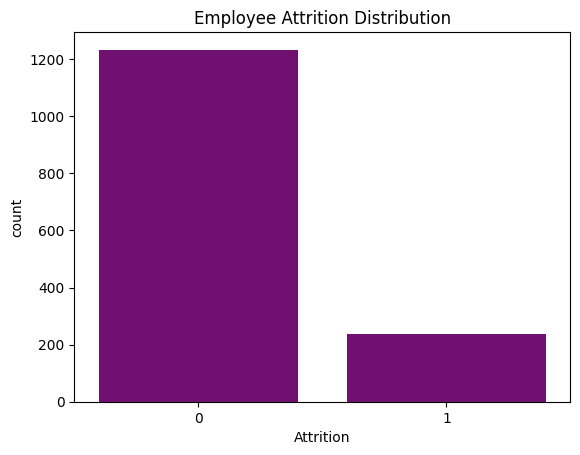

In [37]:
#Create Attrition distribution plot
sns.countplot(x='Attrition', data=IBM_HR_data,color='purple')#create count plot
plt.title("Employee Attrition Distribution")#add title
plt.show()#display plot

**Attrition Distribution Plot Insights:**

- Class 0 (Stay) includes majority of employees.
- Class 1 (Leave) includes minority class.
- This plot confirms dataset is imbalanced.

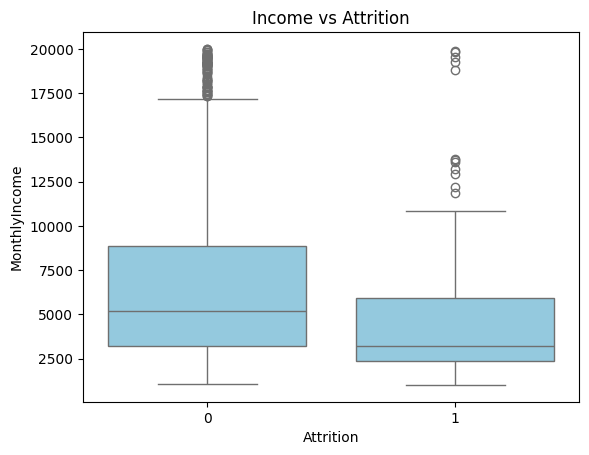

In [38]:
#Create Income vs Attrition plot
sns.boxplot(x='Attrition', y='MonthlyIncome', data=IBM_HR_data,color='skyblue')#create boxplot
plt.title("Income vs Attrition")#add title
plt.show()#display plot

**Income vs Attrition Plot Insights:**

- Employees who leave generally have lower monthly income.
- Higher-income employees are more likely to stay.
- This plot shows salary plays a strong role in retention.
- Class 0 shows outlier after 17500 monthly income and class 1 shows outlier after 12000 monthly income.

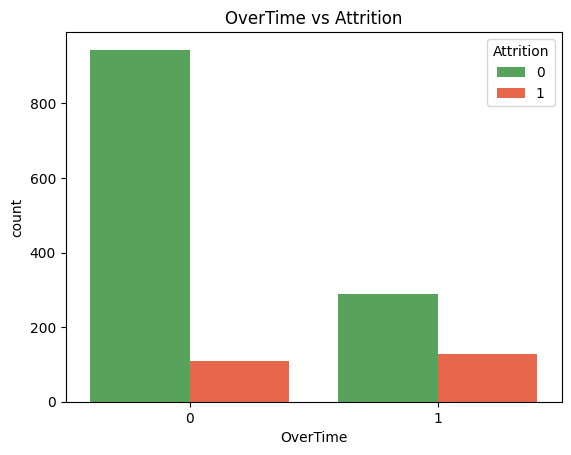

In [39]:
#Create OverTime vs Attrition plot
sns.countplot(x='OverTime', hue='Attrition', data=IBM_HR_data,palette=['#4CAF50', '#FF5733'])#create countplot
plt.title("OverTime vs Attrition")#add title
plt.show()#display plot

**Overtime vs Attrition Plot Insights:**

- Employees working overtime are more likely to leave.
- Attrition rate is higher among overtime workers.
- This plot shows overTime is a critical risk factor.

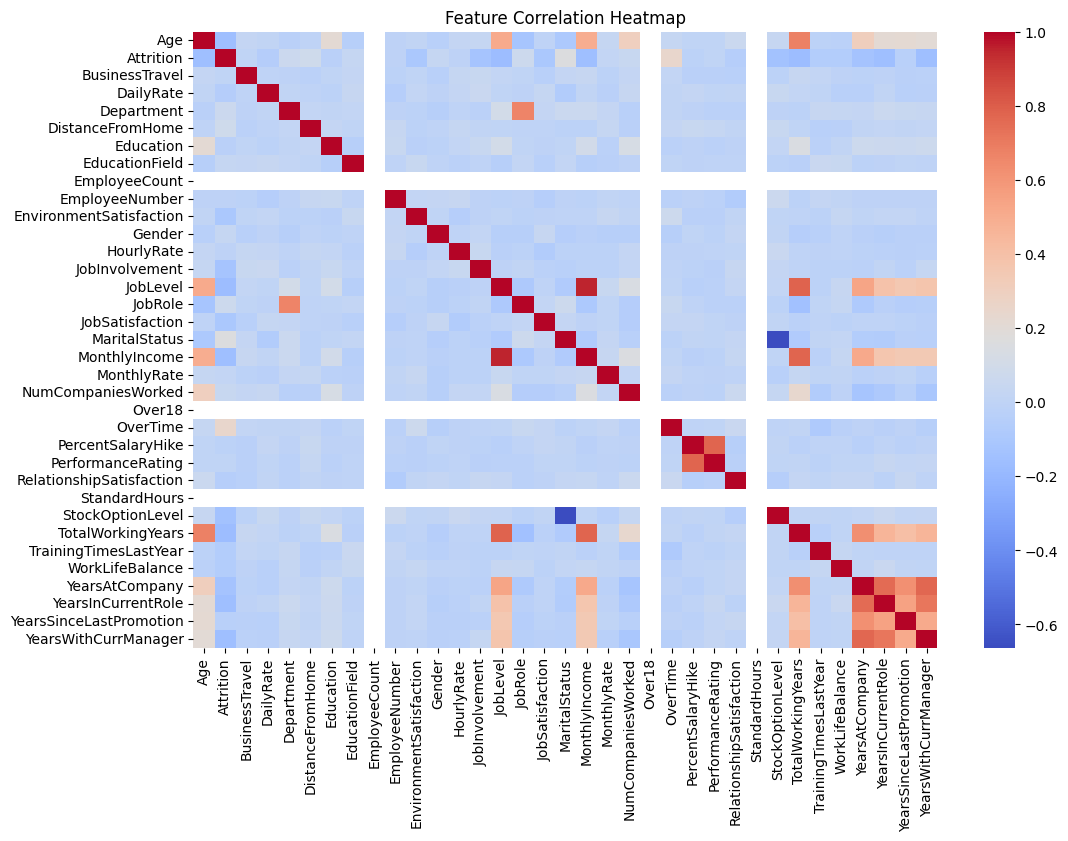

In [40]:
#Create correlation heatmap
plt.figure(figsize=(12,8))#set plot size
sns.heatmap(IBM_HR_data.corr(), cmap='coolwarm')#create heatmap
plt.title("Feature Correlation Heatmap")#add title
plt.show()#display plot

**Correlation Heatmap Insights:**

- The feature correlation heatmap shows the relationships between different variables in the employee attrition dataset.
- Strong positive correlations were observed between MonthlyIncome and JobLevel, MonthlyIncome and TotalWorkingYears, indicating that employees with higher job levels and more work experience tend to earn higher salaries.
- Similarly, YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion and YearsWithCurrManager are highly correlated, suggesting that employees who stay longer in the company often remain in the same role and under the same manager for extended periods.
- A moderate positive correlation was also found between PerformanceRating and PercentSalaryHike, showing that better-performing employees are likely to receive higher salary increases.

- Attrition itself showed weak correlation with individual features, indicating that employee turnover is influenced by a combination of multiple factors rather than a single variable.

- Additionally, features such as EmployeeCount, StandardHours, and Over18 showed little to no variation and provide minimal predictive value.

#Summary Insights of Visualization:

- Overtime is the strongest behavioral predictor of attrition.
- Lower monthly income increases likelihood of leaving.
- Employee tenure (YearsAtCompany, TotalWorkingYears) strongly influences retention.
- Dataset is imbalanced, affecting recall for attrition prediction.
- Model is accurate overall but needs improvement for detecting employees who leave.

**Splitting Dataset:**

In [41]:
# Features and target
X = IBM_HR_data.drop('Attrition', axis=1)#select independent variable
y = IBM_HR_data['Attrition']#select dependent variable

# Split data into 80% training and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Feature Scaling:**

In [42]:
# Initialize StandardScaler to standardize features by removing the mean and scaling to unit variance
# This ensures all numerical features are on the same scale, improving model performance
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train = scaler.fit_transform(X_train)

# Apply the same transformation to test data using the parameters learned from training data
X_test = scaler.transform(X_test)

# Task-3 Model Selection and Development:

For the IBM HR Analytics Employee Attrition & Performance Dataset, the problem is a supervised classification task, because the target variable (Attrition) is categorical (Yes/No), indicating whether an employee leaves the company or not.

**Appropriate model selection:**

For this dataset, the most suitable model is Random Forest Classifier (primary model) because it provides a strong balance between accuracy, robustness and interpretability, which is important for HR decision-making.For improved performance, XGBoost or Gradient Boosting can also be experimented with after baseline modeling.

**Train selected model using the training data:**

In [43]:
# Initialize model
rf_model = RandomForestClassifier(random_state=42)

# Train model on tarining data
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

**Hyperparameter Tuning:**

In [16]:
# Define a grid of hyperparameters for tuning the Random Forest model.This includes different values for number of trees,
#tree depth, minimum samples required for splitting and leaf nodes

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize GridSearchCV to find the best combination of hyperparameters using cross-validation (cv=5) and accuracy as the evaluation metric
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit the model on training data to search for best hyperparameters
grid_search.fit(X_train, y_train)

# Extract the best performing model from GridSearchCV
best_model = grid_search.best_estimator_

**Cross-Validation for Robustness:**

In [17]:
# Perform K-Fold Cross-Validation to evaluate the stability and robustness of the trained model
# The dataset is split into 5 folds (cv=5) and the model is trained and tested 5 times
# Each time, a different fold is used as the validation set
cv_scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

# Print accuracy scores for each fold
print("Cross-validation accuracy scores:", cv_scores)

# Print the average accuracy across all folds and this gives a more reliable estimate of model performance
print("Mean CV accuracy:", round(cv_scores.mean(), 4))

Cross-validation accuracy scores: [0.86440678 0.86382979 0.84680851 0.85531915 0.86808511]
Mean CV accuracy: 0.8597


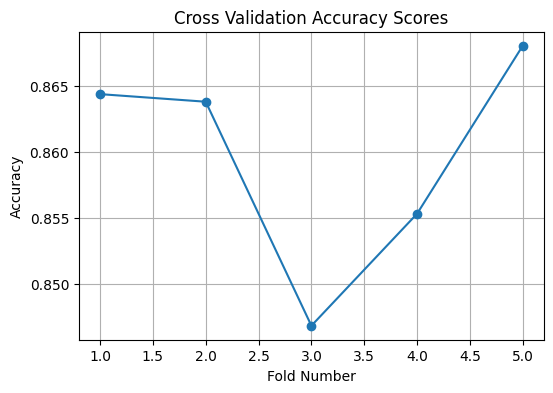

In [18]:
plt.figure(figsize=(6,4))#set plot size
#create cv scores plot
plt.plot(range(1,6), cv_scores, marker='o')
#Add title, label of axis and grid
plt.title("Cross Validation Accuracy Scores")
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()#display plot

**Cross Validation Insights:**

- Mean CV Accuracy is 0.8597
- CV scores show consistent performance across folds as [0.8644, 0.8638, 0.8468, 0.8553, 0.8681]
- This score indicates the model is stable and not highly overfitted.

# Task-4 Model Evaluation and Optimization:

**Model Evaluation:**

In [19]:
# Make predictions on the test dataset using the trained best model
y_pred = best_model.predict(X_test)

# Get predicted probabilities for the positive class needed for AUC-ROC calculation
y_proba = best_model.predict_proba(X_test)[:, 1]

# Evaluate model performance using different classification metrics
# Compute Accuracy(Overall correctness of predictions)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))

# Compute Precision (How many predicted positive cases are actually correct)
print("Precision:", round(precision_score(y_test, y_pred), 4))

# Compute Recall (How many actual positive cases were correctly identified)
print("Recall:", round(recall_score(y_test, y_pred), 4))

# Compute F1 Score (Harmonic mean of precision and recall (balance between both))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))

# Find AUC-ROC used to measures model's ability to distinguish between classes
print("AUC-ROC:", round(roc_auc_score(y_test, y_proba), 4))

# Detailed classification report including precision, recall, F1-score per class
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8639
Precision: 0.4444
Recall: 0.1026
F1 Score: 0.1667
AUC-ROC: 0.7064

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.98      0.93       255
           1       0.44      0.10      0.17        39

    accuracy                           0.86       294
   macro avg       0.66      0.54      0.55       294
weighted avg       0.82      0.86      0.83       294



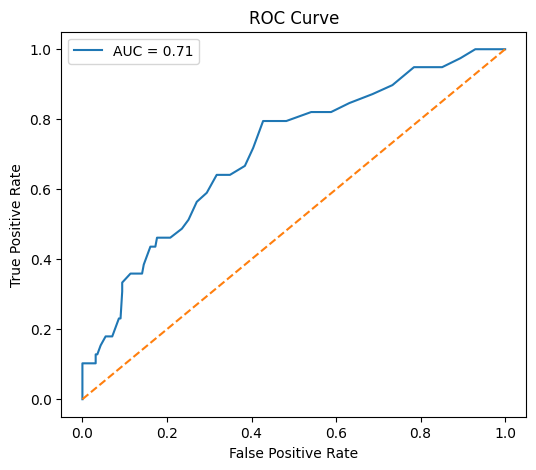

In [21]:
#Create ROC curve
#take fpr,tpr,thresholds and roc_auc value
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))#set plot size
#Create plot
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1], [0,1], linestyle='--')
#Add label of axis and title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()#show legend
plt.show()#display plot

**Model Evaluation Insights:**

- The Random Forest model achieved an overall accuracy of 86.39%, indicating strong general performance in predicting employee attrition.
- The model also obtained a precision of 44.44%, meaning that when it predicts an employee will leave, it is correct nearly half of the time.
- However, the recall is very low at 10.26%, showing that the model fails to identify many employees who actually leave the company. This is further reflected in the low F1-score of 16.67%, which indicates poor balance between precision and recall for attrition prediction.
- The AUC-ROC score of 70.64% suggests that the model has moderate capability in distinguishing between employees who stay and those who leave.
- From the classification report, the model performs extremely well for employees who stay (Class 0) with a precision of 0.88 and recall of 0.98, correctly identifying most employees who remain in the organization.
- However, for employees who leave (Class 1), the model performs poorly with a recall of only 0.10, meaning many actual attrition cases are missed. This issue occurs mainly due to class imbalance in the dataset, where significantly more employees stay than leave.
- Overall, while the model demonstrates strong overall accuracy, improvements such as handling class imbalance using techniques like SMOTE, class weighting, or threshold tuning could help improve attrition prediction performance.

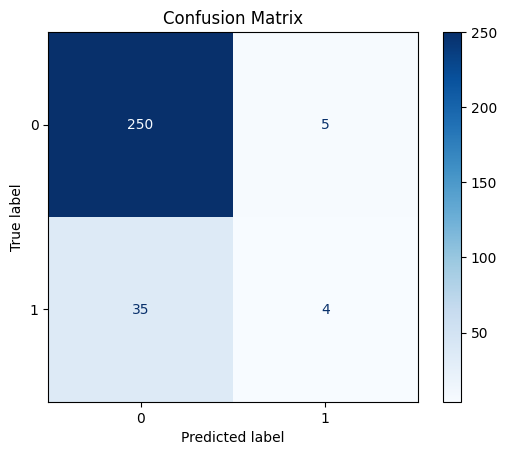

In [20]:
cm = confusion_matrix(y_test, y_pred)#compute confusion matrix
#Create plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
#Add title
plt.title("Confusion Matrix")
plt.show()#display plot

**Confusion Matrix Insights:**

- 250 True Negatives (TN) shows the model correctly predicted that 250 employees would stay in the company.
- 4 True Positives (TP) shows the model correctly predicted only 4 employees who actually left.
- 5 False Positives (FP) shows the model incorrectly predicted that 5 employees would leave when they actually stayed.
- 35 False Negatives (FN) shows the model failed to identify 35 employees who actually left.
- The model performs very well in predicting employees who stay (high true negatives) but struggles to correctly identify employees who leave (high false negatives) because model accuracy is high (86%) and recall is very low (10%).

**Hyperparameter Tuning for Optimization:**

In [22]:
# Initialize RandomizedSearchCV for hyperparameter tuning of the Random Forest model
random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_grid,  # hyperparameter search space
    n_iter=20,                       # number of random combinations to try
    cv=5,                            # 5-fold cross-validation for reliable evaluation
    scoring='f1',                    # F1-score used as evaluation metric (good for imbalance cases)
    random_state=42,
    n_jobs=-1                        # uses all CPU cores for faster execution
)

# Fit the model on training data to search for best hyperparameters
random_search.fit(X_train, y_train)

# Extract the best model obtained from Randomized Search
best_model1 = random_search.best_estimator_

In [23]:
# Perform feature selection using feature importance from the trained Random Forest model
# Random Forest assigns an importance score to each feature based on how useful it is for prediction
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model1.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Display features ranked from most important to least important
print('Important Features:')
print(feature_importance)

Important Features:
                     Feature  Importance
17             MonthlyIncome    0.074968
21                  OverTime    0.064823
0                        Age    0.056865
2                  DailyRate    0.050505
27         TotalWorkingYears    0.048104
18               MonthlyRate    0.047090
8             EmployeeNumber    0.045296
11                HourlyRate    0.043352
4           DistanceFromHome    0.042012
30            YearsAtCompany    0.041914
19        NumCompaniesWorked    0.036035
14                   JobRole    0.032731
22         PercentSalaryHike    0.032530
26          StockOptionLevel    0.031840
33      YearsWithCurrManager    0.028512
31        YearsInCurrentRole    0.027299
13                  JobLevel    0.026893
32   YearsSinceLastPromotion    0.026549
28     TrainingTimesLastYear    0.025413
15           JobSatisfaction    0.025368
16             MaritalStatus    0.025151
9    EnvironmentSatisfaction    0.024602
6             EducationField    0.023

/tmp/ipykernel_1552/2852122041.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance',y='Feature',data=top_10_features,palette='viridis')


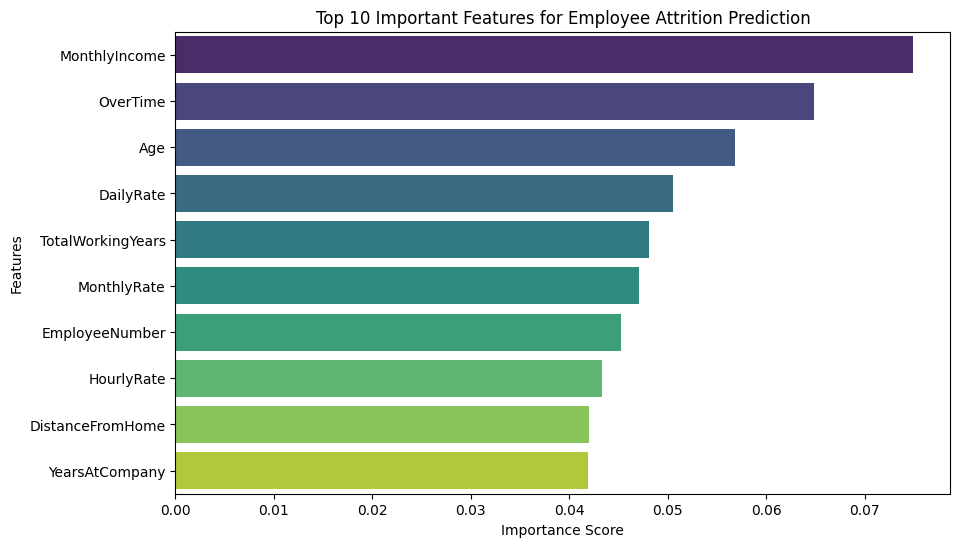

In [24]:
# Select top 10 important features
top_10_features = feature_importance.head(10)

plt.figure(figsize=(10,6))#set plot size

# Create plot to show top 10 important features
sns.barplot(x='Importance',y='Feature',data=top_10_features,palette='viridis')

# Add title and label of axis
plt.title("Top 10 Important Features for Employee Attrition Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()# display plot

**Important Features Insights:**

- Top influencing features from the mode are MonthlyIncome (0.0749)
,OverTime (0.0648), Age (0.0568),TotalWorkingYears (0.0481 and YearsAtCompany (0.0419).
- These results indicate that financial factors, overtime and experience-related features are the strongest predictors of attrition.

**Note:**

Regularization techniques such as L1/L2 and dropout were not applied because the selected model was Random Forest, which is a tree-based ensemble algorithm. Instead, overfitting was controlled by tuning parameters such as maximum tree depth, minimum samples required for splitting and the number of trees to improve model generalization.

# Task-5 Model Deployment:

**Note:**

Due to my personnel google account credentials,I have not deploy my model in google colab but save into pickle file using joblib library and pergorm all deployment steps.

In [25]:
# Save model
joblib.dump(best_model1, 'attrition_model.pkl')

['attrition_model.pkl']

In [26]:
!pip install gradio

In [27]:
# Load model
loaded_model = joblib.load('attrition_model.pkl')

print("Model loaded successfully!")

Model loaded successfully!


In [28]:
#Store all feature names in feature_names variable
feature_names = [
    'Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome',
    'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber',
    'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
    'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
    'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18',
    'OverTime', 'PercentSalaryHike', 'PerformanceRating',
    'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
    'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
    'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
    'YearsWithCurrManager'
]

# Select the top 8 most important features based on feature importance ranking
# These features have the highest impact on predicting employee attrition
top_features = feature_importance['Feature'].head(8).tolist()

# Convert training and testing data back into DataFrame format
# This ensures that column names are properly aligned with feature names
X_train = pd.DataFrame(X_train, columns=feature_names)
X_test = pd.DataFrame(X_test, columns=feature_names)

# Select only the top important features from the training dataset
# This reduces dimensionality and improves model efficiency
X_train_selected = X_train.loc[:, top_features]

# Select the same important features from the test dataset ensures consistency between training and testing data
X_test_selected = X_test.loc[:, top_features]

# Train the Random Forest model using only the selected important features
# This improves interpretability and reduces overfitting
best_model1.fit(X_train_selected, y_train)

RandomForestClassifier(max_depth=30, random_state=42)

In [29]:
#Import library
import gradio as gr

# Define full feature list used during training (34 features)
feature_names = [
    'Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome',
    'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber',
    'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
    'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
    'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18',
    'OverTime', 'PercentSalaryHike', 'PerformanceRating',
    'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
    'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
    'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
    'YearsWithCurrManager'
]

# Prediction function for Gradio interface
def predict_attrition(age, monthly_income, job_satisfaction, overtime):

    # Convert categorical input (OverTime) into numeric format
    overtime_value = 1 if overtime == "Yes" else 0

    # Create empty input array with 34 features (default = 0)
    input_data = np.zeros((1, len(feature_names)))

    # Fill only selected important features
    input_data[0][feature_names.index("Age")] = age
    input_data[0][feature_names.index("MonthlyIncome")] = monthly_income
    input_data[0][feature_names.index("JobSatisfaction")] = job_satisfaction
    input_data[0][feature_names.index("OverTime")] = overtime_value

    # Predict using trained model
    prediction = loaded_model.predict(input_data)[0]

    # Return human-readable output
    if prediction == 1:
        return "Employee is likely to leave the company"
    else:
        return "Employee is likely to stay in the company"


# ---------------- GRADIO INTERFACE ----------------

# Create user-friendly UI for input and prediction
interface = gr.Interface(
    fn=predict_attrition,
    inputs=[
        gr.Number(label="Age"),#textbox creation
        gr.Number(label="Monthly Income"),#textbox creation
        gr.Dropdown([1, 2, 3, 4], label="Job Satisfaction"),#create dropdown with value
        gr.Dropdown(["Yes", "No"], label="OverTime")#create dropdown with value
    ],
    outputs="text",
    title="Employee Attrition Prediction System",
    description="Enter employee details to predict whether an employee will leave or stay."
)

# Launch the application in Google Colab
interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7d7dd8ee7512aa07c1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


The successful deployment of the employee attrition prediction model through a Gradio interface demonstrates that the trained model can be used in a real-world HR setting. The user-friendly interface allows users to input employee details such as age, monthly income, job satisfaction, and overtime status and instantly receive attrition predictions. This shows that the model is not only capable of learning patterns from historical employee data but can also be integrated into an interactive system for practical decision-making. Organizations can use this tool to identify employees at risk of leaving and take proactive retention measures. The deployment phase highlights the practical applicability of machine learning in solving real-world business problems through accessible and interactive interfaces.